# 04 — QAOA depth sweep

**Sweep 1.** Fixed problem — the canonical 16-equity universe with `K=4`.
Vary `p in {1..5}`. For each `p` we run 50 multi-start COBYLA seeds and
keep the best, then report approximation ratio, P(optimum), and
P(feasible) across `p`.

We also rerun the sweep with **warm starts** (Zhou et al. 2018): at
depth `p` the optimiser is seeded from the depth-`(p-1)` best angles
plus one fresh random layer, then refined with COBYLA. This separates
restart-budget pathology (non-monotonicity that random multi-start can
fix by spending more compute) from genuine ansatz limits (non-monotonicity
that warm starts also cannot fix).

Results cache to `results/depth_sweep.json` (random multi-start) and
`results/depth_sweep_warm.json` (warm starts). Re-plotting is instant.

> **Runtime:** ~30 min on Colab CPU for 50 restarts × 5 depths × 2
> protocols (instant on cache hit).

In [1]:
# === Bootstrap (Colab + local) ===
import os, urllib.request as _u
exec((open('../scripts/bootstrap.py') if os.path.exists('../scripts/bootstrap.py') else _u.urlopen('https://raw.githubusercontent.com/egil10/fys5419/main/project2/code/scripts/bootstrap.py')).read())

# === Project imports ===
import json
import numpy as np
import pandas as pd

from scripts.colab     import out_dir
from scripts.data      import load_universe
from scripts.portfolio import PortfolioProblem, DEFAULTS
from scripts.classical import brute_force
from scripts.qaoa      import solve
from scripts.metrics   import prob_optimal, prob_feasible

RESULTS = out_dir('results')
print(f'Results will be saved to: {RESULTS}')

> /usr/bin/python3 -m pip install -q numpy pandas scipy matplotlib yfinance pyarrow
[colab.setup] env=Colab
[colab.setup] cwd  = /content/fys5419/project2/code/notebooks
[colab.setup] path = /content/fys5419/project2/code  (added to sys.path)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results will be saved to: /content/drive/MyDrive/GITHUB-COLAB/fys5419/project2/code/results


In [2]:
# === Canonical instance: n=16, K=4 ===
P_VALUES   = [1, 2, 3, 4, 5]
N_RESTARTS = 50          # bumped from 10 -> 50 to settle the non-monotonicity
                         # at p>=3 reported with the old budget. With 50
                         # COBYLA restarts the optimiser is far less likely
                         # to be the bottleneck, so any residual ratio dip
                         # at high p is structural rather than budgetary.

r  = load_universe()
pf = PortfolioProblem(r.mu, r.Sigma,
                      lam=DEFAULTS['lam'], A=DEFAULTS['A'],
                      K=DEFAULTS['K_AT_16'], tickers=r.tickers)
bf = brute_force(pf)
print(f'brute force: {bf.bitstring}  C={bf.cost:.6f}  picks={bf.tickers(pf)}')

brute force: 0010000010010001  C=-0.001404  picks=['GOOGL', 'IBM', 'NVDA', 'JPM']


In [3]:
cache = RESULTS / 'depth_sweep.json'

if cache.exists():
    sweep = json.loads(cache.read_text())
    print(f'loaded {cache.name}')
else:
    sweep = []
    for p in P_VALUES:
        res = solve(pf, p=p, n_restarts=N_RESTARTS, seed=42)
        e_opt   = float(res['ground_state_energy'])
        e_worst = float(res['worst_energy'])
        gap_rel = (float(res['energy']) - e_opt) / abs(e_opt) if e_opt != 0 else float('inf')
        sweep.append({
            'p':           p,
            'energy':      float(res['energy']),
            'ratio':       float(res['ratio']),   # scaled (E_worst-E)/(E_worst-E_opt) in [0,1]
            'gap_rel':     gap_rel,               # (E - E_opt)/|E_opt|; 0 = optimal
            'e_opt':       e_opt,
            'e_worst':     e_worst,
            'p_optimal':   prob_optimal(res['probs'], bf.x),
            'p_feasible':  prob_feasible(res['probs'], pf.n, pf.K),
            'best_C':      float(min(h['fun'] for h in res['history'])),
        })
        print(f'  p={p}: ratio={res["ratio"]:.4f}  gap_rel={gap_rel:.2e}  '
              f'P(opt)={sweep[-1]["p_optimal"]:.4f}  '
              f'P(feas)={sweep[-1]["p_feasible"]:.4f}')
    cache.write_text(json.dumps(sweep, indent=2))
    print(f'saved -> {cache.name}')

pd.DataFrame(sweep)

  p=1: ratio=0.9910  gap_rel=4.61e+02  P(opt)=0.0002  P(feas)=0.3812
  p=2: ratio=0.9955  gap_rel=2.30e+02  P(opt)=0.0003  P(feas)=0.5467
  p=3: ratio=0.9900  gap_rel=5.16e+02  P(opt)=0.0001  P(feas)=0.2494
  p=4: ratio=0.9748  gap_rel=1.30e+03  P(opt)=0.0004  P(feas)=0.6283
  p=5: ratio=0.9747  gap_rel=1.30e+03  P(opt)=0.0001  P(feas)=0.2253
saved -> depth_sweep.json


,p,energy,ratio,gap_rel,e_opt,e_worst,p_optimal,p_feasible,best_C
0,1,0.645595,0.991040,460.676415,-0.001404,72.205957,0.000210,0.381161,0.645595
1,2,0.321319,0.995531,229.785735,-0.001404,72.205957,0.000287,0.546702,0.321319
2,3,0.722811,0.989970,515.655797,-0.001404,72.205957,0.000128,0.249376,0.722811
3,4,1.818292,0.974799,1295.660546,-0.001404,72.205957,0.000385,0.628323,1.818292
4,5,1.822682,0.974738,1298.786743,-0.001404,72.205957,0.000109,0.225271,1.822682


### Warm-start protocol (Zhou et al. 2018)

At depth `p`, seed the COBYLA optimiser at the depth-`(p-1)` optimum with
one freshly-sampled extra layer appended. This costs the same per-`p` as a
single COBYLA call (cheap), but matches the literature prescription for
disentangling restart-budget pathology from genuine ansatz limits.

We still run a small random multi-start (`N_WARM_RESTARTS=10`) per `p`
*on top* of the warm seed, choosing the best — so the comparison vs the
random-only protocol is "same restart budget, smarter inits".

In [4]:
from scripts.qaoa import solve_warm  # added alongside `solve` in scripts/qaoa.py

cache_w = RESULTS / 'depth_sweep_warm.json'
N_WARM_RESTARTS = 10                  # cheap: warm seeds dominate the budget

if cache_w.exists():
    sweep_w = json.loads(cache_w.read_text())
    print(f'loaded {cache_w.name}')
else:
    sweep_w = []
    prev = None  # (gammas, betas) from the depth-(p-1) optimum
    for p in P_VALUES:
        res = solve_warm(pf, p=p, prev=prev,
                         n_restarts=N_WARM_RESTARTS, seed=42)
        e_opt   = float(res['ground_state_energy'])
        e_worst = float(res['worst_energy'])
        gap_rel = (float(res['energy']) - e_opt) / abs(e_opt) if e_opt != 0 else float('inf')
        sweep_w.append({
            'p':           p,
            'energy':      float(res['energy']),
            'ratio':       float(res['ratio']),
            'gap_rel':     gap_rel,
            'e_opt':       e_opt,
            'e_worst':     e_worst,
            'p_optimal':   prob_optimal(res['probs'], bf.x),
            'p_feasible':  prob_feasible(res['probs'], pf.n, pf.K),
            'best_C':      float(min(h['fun'] for h in res['history'])),
        })
        prev = (np.asarray(res['gammas']), np.asarray(res['betas']))
        print(f'  p={p}: ratio={res["ratio"]:.4f}  gap_rel={gap_rel:.2e}  '
              f'P(opt)={sweep_w[-1]["p_optimal"]:.4f}  '
              f'P(feas)={sweep_w[-1]["p_feasible"]:.4f}')
    cache_w.write_text(json.dumps(sweep_w, indent=2))
    print(f'saved -> {cache_w.name}')

pd.DataFrame(sweep_w)

  p=1: ratio=0.9910  gap_rel=4.61e+02  P(opt)=0.0002  P(feas)=0.3812
  p=2: ratio=0.9952  gap_rel=2.46e+02  P(opt)=0.0003  P(feas)=0.5473
  p=3: ratio=0.9958  gap_rel=2.17e+02  P(opt)=0.0003  P(feas)=0.5855
  p=4: ratio=0.9961  gap_rel=2.01e+02  P(opt)=0.0003  P(feas)=0.6058
  p=5: ratio=0.9968  gap_rel=1.66e+02  P(opt)=0.0003  P(feas)=0.6250
saved -> depth_sweep_warm.json


,p,energy,ratio,gap_rel,e_opt,e_worst,p_optimal,p_feasible,best_C
0,1,0.645595,0.991040,460.676500,-0.001404,72.205957,0.000210,0.381196,0.645595
1,2,0.344778,0.995206,246.488996,-0.001404,72.205957,0.000303,0.547348,0.344778
2,3,0.304004,0.995770,217.457264,-0.001404,72.205957,0.000325,0.585520,0.304004
3,4,0.280991,0.996089,201.071092,-0.001404,72.205957,0.000336,0.605783,0.280991
4,5,0.231580,0.996773,165.889779,-0.001404,72.205957,0.000348,0.624986,0.231580


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


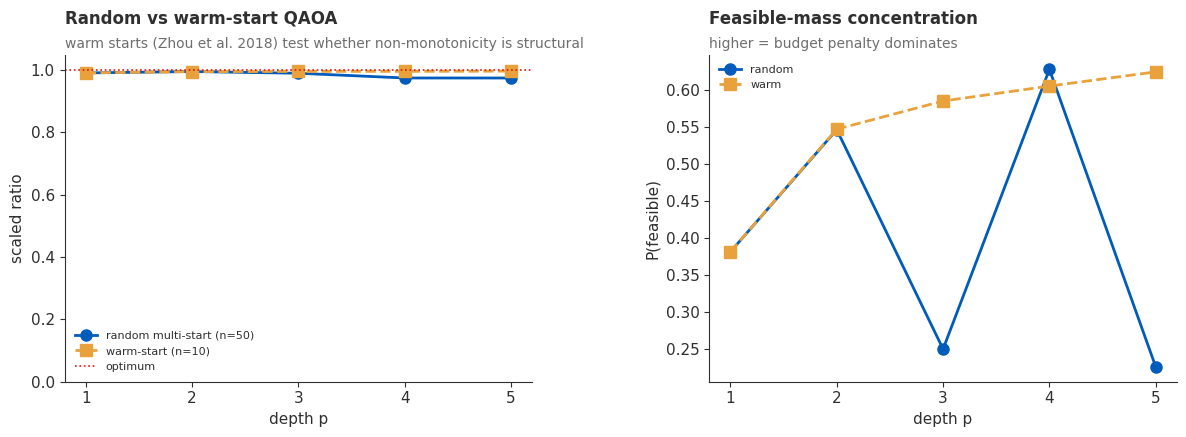

In [5]:
# === Random multi-start vs warm-start side-by-side ===
import matplotlib.pyplot as plt
from scripts.plotting import apply_style, PALETTE, title, fig_path
apply_style()

df_r = pd.DataFrame(sweep)
df_w = pd.DataFrame(sweep_w)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(df_r.p, df_r.ratio, 'o-', color=PALETTE['blue'],   lw=2, ms=8,
             label=f'random multi-start (n={N_RESTARTS})')
axes[0].plot(df_w.p, df_w.ratio, 's--', color=PALETTE['ochre'], lw=2, ms=8,
             label=f'warm-start (n={N_WARM_RESTARTS})')
axes[0].axhline(1.0, color=PALETTE['red'], ls=':', lw=1.2, label='optimum')
axes[0].set_xticks(df_r.p); axes[0].set_xlabel('depth p')
axes[0].set_ylabel(r'scaled ratio')
axes[0].set_ylim(0.0, 1.05)
title(axes[0], 'Random vs warm-start QAOA',
      'warm starts (Zhou et al. 2018) test whether non-monotonicity is structural')
axes[0].legend(fontsize=8); axes[0].grid(False)

axes[1].plot(df_r.p, df_r.p_feasible, 'o-', color=PALETTE['blue'],   lw=2, ms=8, label='random')
axes[1].plot(df_w.p, df_w.p_feasible, 's--', color=PALETTE['ochre'], lw=2, ms=8, label='warm')
axes[1].set_xticks(df_r.p); axes[1].set_xlabel('depth p'); axes[1].set_ylabel('P(feasible)')
title(axes[1], 'Feasible-mass concentration', 'higher = budget penalty dominates')
axes[1].legend(fontsize=8); axes[1].grid(False)

plt.tight_layout()
fig.savefig(fig_path('compare', 'depth_warm_vs_random'), bbox_inches='tight')
plt.show()